# Init

In [168]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.metrics import RocCurveDisplay

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

In [131]:
seed = 42

# Import data

In [132]:
df = pd.read_excel('data/raw/Z06_dane_proj2.xls', skiprows=[1])

# Basic analysis

In [133]:
df.head()

,status kredytobiorcy,status mieszkania,Dochód I-go kredytob..,Dochód II-go kredytob./żyranta,miejsce zam,poziom wykształcenia I-go,rodzaj wyksztalcenia I-go,wiek I-go kredytob.,staż pracy I-go kredytob.,Aktyw/pasywa I-go kredytobiorcy,...,posiada ROR,posiada debetową ?,Czy korzysta z dostepu do produktów przez intrernet?,Czy ma konto na facebooku,czy ktos z Jego znajomych na facebooku jest w rejestrze ndłuzników?,ile posiada produktów w Naszym banku?,w ilu bankach ma zakupioneprodukty ?,liczba aktualnieposiadanych kredytów,czy był w tym roku na wakacjach zagranicznych?,czy z konta na Facebooku wynika że lubi piwo?
0,0,mieszk. wynajemm,8248.47,3119.35,małe m.,licencjat,biologiczne,62,43,94486.88,...,tak,tak,nie,tak,tak,1,1,1.0,nie,tak
1,0,mieszk. wł.,10134.22,8155.38,osiedle,mgr,techniczne,45,28,21172.64,...,nie,nie,tak,tak,nie,2,1,1.0,nie,nie
2,0,mieszk. wynajemm,10439.73,6974.29,duże m.,mgr,biologiczne,54,34,25393.72,...,nie,tak,tak,nie,nie,2,1,1.0,nie,nie
3,0,mieszk. wł.,8504.42,4570.26,średnie m.,licencjat,techniczne,67,51,34875.15,...,tak,nie,tak,tak,tak,2,1,1.0,nie,nie
4,0,dom,10719.52,6519.09,duże m.,licencjat,ściłe,36,17,13394.70,...,nie,nie,nie,nie,nie,1,1,1.0,tak,nie


In [134]:
df.shape

(2400, 27)

In [135]:
df.describe()

,status kredytobiorcy,Dochód I-go kredytob..,Dochód II-go kredytob./żyranta,wiek I-go kredytob.,staż pracy I-go kredytob.,Aktyw/pasywa I-go kredytobiorcy,Wartość samoch.,ile posiada produktów w Naszym banku?,w ilu bankach ma zakupioneprodukty ?,liczba aktualnieposiadanych kredytów
count,2400.000000,2400.000000,2400.000000,2400.00000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2001.000000
mean,0.500000,9090.803625,6066.292267,39.80500,21.818333,28280.773500,41554.114558,1.540833,1.429583,1.282859
std,0.500104,1855.618821,2624.181570,10.92833,11.007383,19340.056551,18108.783656,1.013045,0.929373,0.769384
min,0.000000,4815.300000,825.770000,18.00000,0.000000,-42947.570000,0.000000,0.000000,1.000000,1.000000
25%,0.000000,7666.852500,3844.235000,32.00000,14.000000,15008.925000,29805.407500,1.000000,1.000000,1.000000
50%,0.500000,8768.680000,5000.840000,40.00000,22.000000,24861.890000,38398.445000,1.000000,1.000000,1.000000
75%,1.000000,10354.072500,8162.000000,48.00000,30.000000,40772.985000,52101.182500,2.000000,1.000000,1.000000
max,1.000000,15208.670000,17497.290000,67.00000,51.000000,130383.860000,138022.280000,4.000000,5.000000,5.000000


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 27 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   status kredytobiorcy                                                 2400 non-null   int64  
 1   status mieszkania                                                    2400 non-null   object 
 2   Dochód I-go kredytob..                                               2400 non-null   float64
 3   Dochód II-go kredytob./żyranta                                       2400 non-null   float64
 4   miejsce zam                                                          2400 non-null   object 
 5   poziom wykształcenia I-go                                            2400 non-null   object 
 6   rodzaj wyksztalcenia I-go                                            2400 non-null   object 
 7   wiek I

In [137]:
df.isna().sum()/len(df) * 100

status kredytobiorcy                                                    0.000
status mieszkania                                                       0.000
Dochód I-go kredytob..                                                  0.000
Dochód II-go kredytob./żyranta                                          0.000
miejsce zam                                                             0.000
poziom wykształcenia I-go                                               0.000
rodzaj wyksztalcenia I-go                                               0.000
wiek I-go kredytob.                                                     0.000
staż pracy I-go kredytob.                                               0.000
Aktyw/pasywa I-go kredytobiorcy                                         0.000
rodzaj zatrudnienia                                                     0.000
miejsce urodzenia I-szego                                               0.000
stan rodzinny                                                   

In [138]:
target_column = "status kredytobiorcy"

num_columns = [
    "Dochód I-go kredytob..",
    "Dochód II-go kredytob./żyranta",
    "wiek I-go kredytob.",
    "staż pracy I-go kredytob.",
    "Aktyw/pasywa I-go kredytobiorcy",
    "Wartość samoch.",
    "ile posiada produktów w Naszym banku?",
    "w ilu bankach ma zakupioneprodukty ?",
]

category_columns = [
    "status mieszkania",
    "miejsce zam",
    "poziom wykształcenia I-go",
    "rodzaj wyksztalcenia I-go",
    "rodzaj zatrudnienia",
    "miejsce urodzenia I-szego",
    "stan rodzinny",
    "rodzaj pracodawcy",
    "wielkość pracodawcy",
]

bool_columns = [
    "posiada kartę kredytową ?",
    "posiada  ROR",
    "posiada debetową ?",
    "Czy korzysta z dostepu do produktów przez intrernet?",
    "Czy ma konto na facebooku",
    "czy ktos z Jego znajomych na facebooku jest w rejestrze ndłuzników?",

]

columns_to_drop = [
    "liczba aktualnieposiadanych kredytów",
    "czy był w tym roku na wakacjach zagranicznych?",
    "czy z konta na Facebooku wynika że lubi piwo?",
]

full_count = [target_column] + num_columns + category_columns + bool_columns + columns_to_drop
assert len(full_count) == df.shape[1]

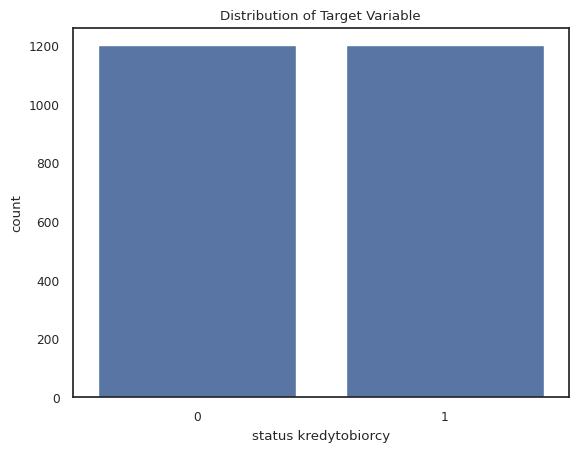

In [139]:
# Visualize target distribution
sns.countplot(data=df, x=target_column)
plt.title('Distribution of Target Variable')
plt.show()

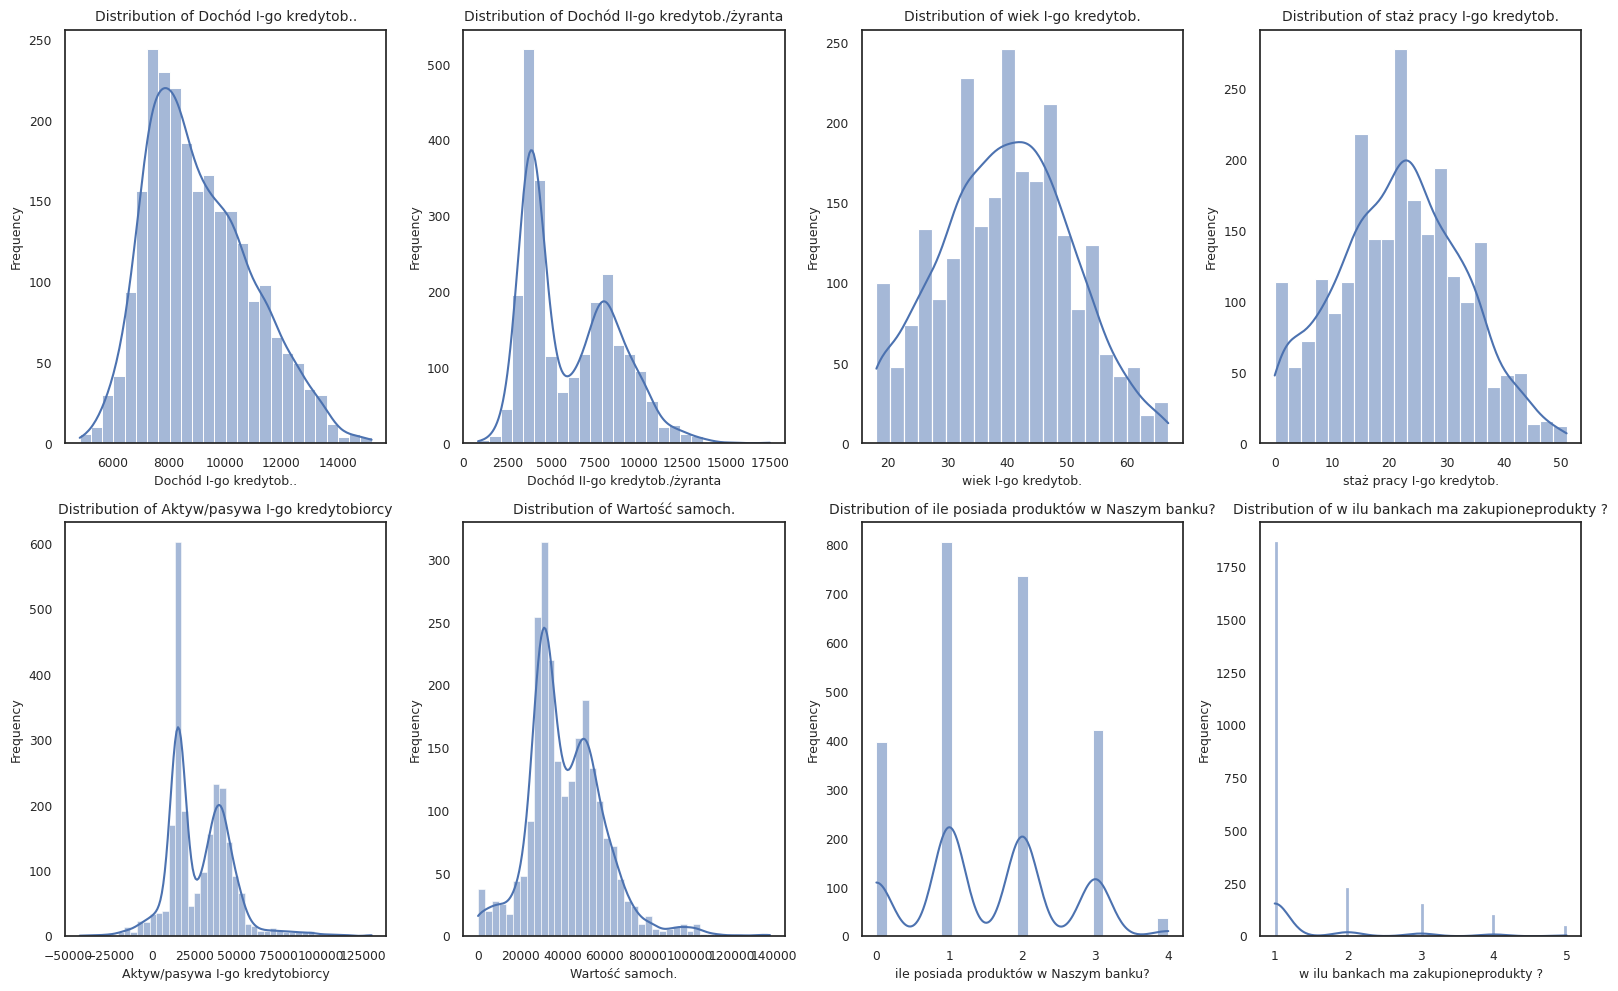

In [140]:
# Visualize numeric features
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(num_columns):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}', fontsize=10)
    axes[idx].set_xlabel(col, fontsize=9)
    axes[idx].set_ylabel('Frequency', fontsize=9)

plt.tight_layout()
plt.show()

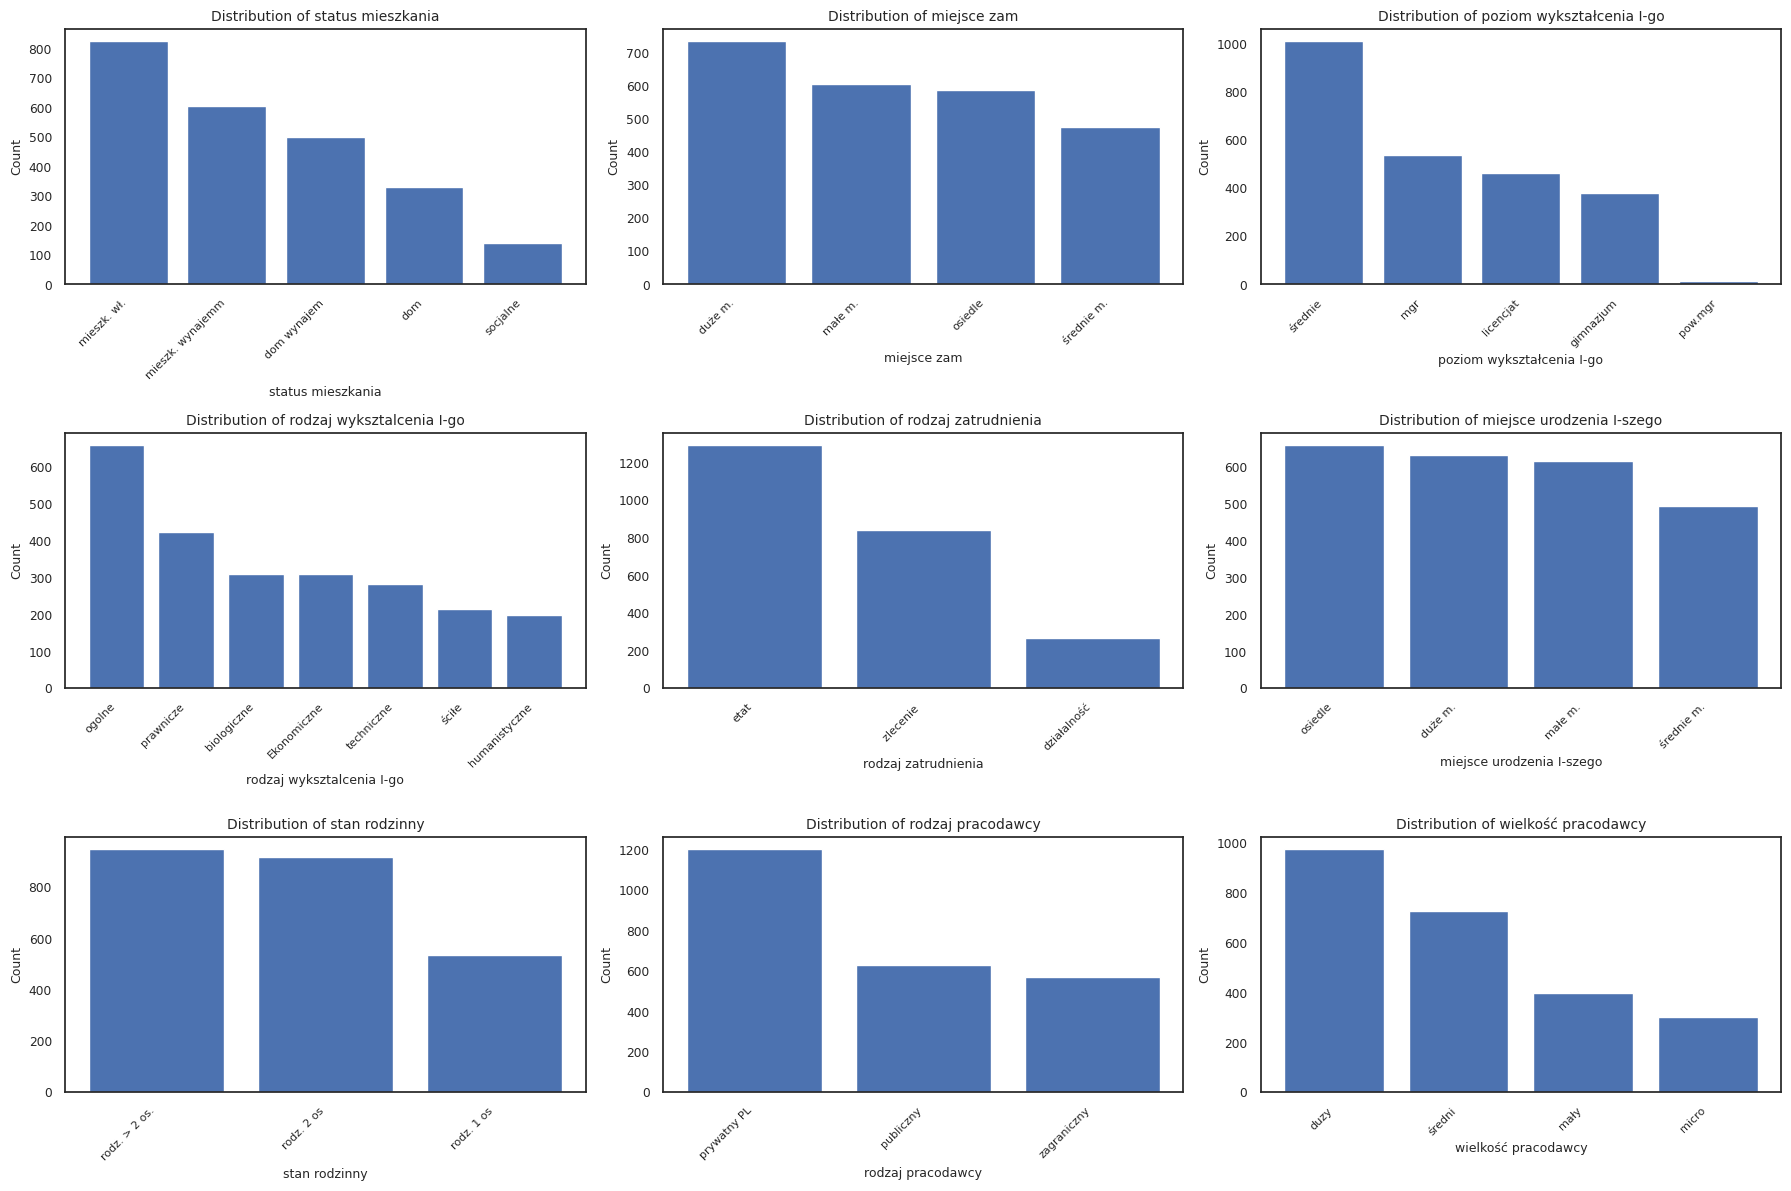

In [141]:
# Visualize category columns
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(category_columns):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values)
    axes[idx].set_title(f'Distribution of {col}', fontsize=10)
    axes[idx].set_xlabel(col, fontsize=9)
    axes[idx].set_ylabel('Count', fontsize=9)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

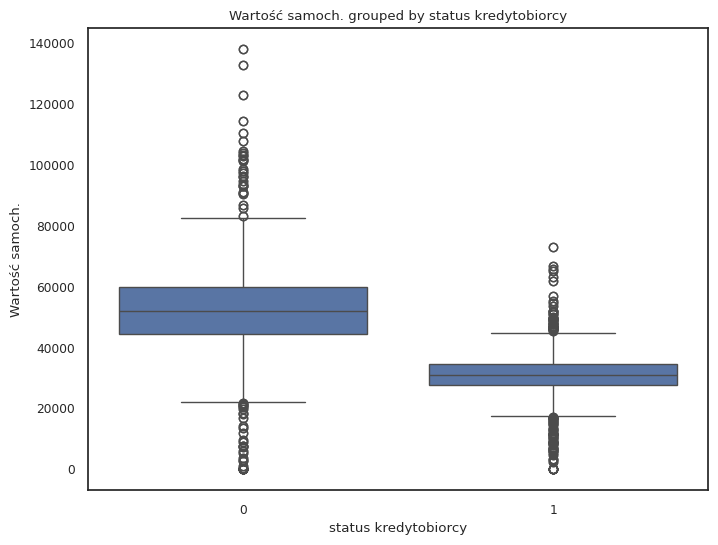

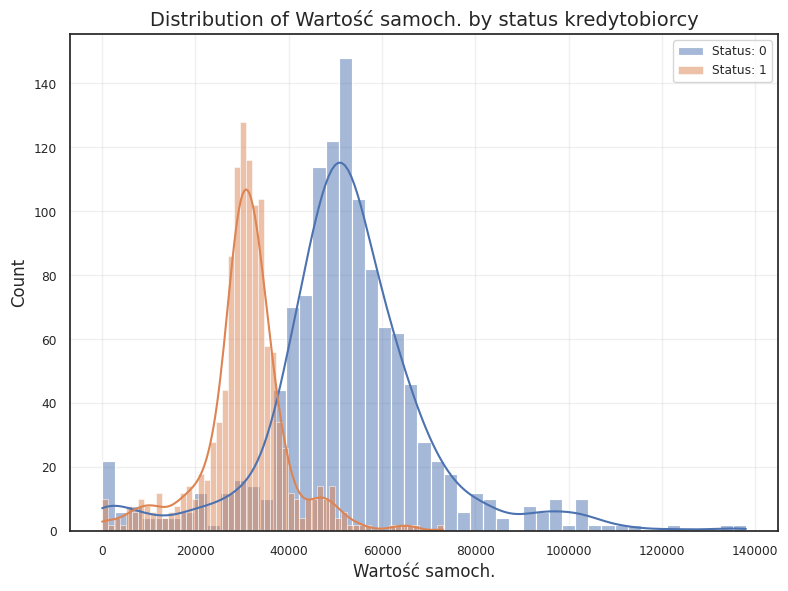

In [178]:
# Wartość samoch. grouped by status kredytobiorcy
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x=target_column, y='Wartość samoch.')
plt.title('Wartość samoch. grouped by status kredytobiorcy')
plt.xlabel('status kredytobiorcy')
plt.ylabel('Wartość samoch.')
plt.show()

# Distribution Wartość samoch. grouped by target variable (overlapped)
plt.figure(figsize=(8, 6))
for class_label in df[target_column].unique():
    subset = df[df[target_column] == class_label]['Wartość samoch.']
    sns.histplot(subset, kde=True, label=f'Status: {class_label}', alpha=0.5)

plt.xlabel('Wartość samoch.', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Wartość samoch. by status kredytobiorcy', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# Data Preparation

## Columns removal

Analysis shows missing data for 3 variables:
* liczba aktualnieposiadanych kredytów
* czy był w tym roku na wakacjach zagranicznych?
* czy z konta na Facebooku wynika że lubi piwo?

These variables will be removed

In [142]:
df = df.drop(columns=columns_to_drop)

## Category columns transformation

In [143]:
encoder = OneHotEncoder(sparse_output=False, drop='first')

for col in category_columns:
    transformed = encoder.fit_transform(df[[col]])
    transformed_df = pd.DataFrame(transformed, columns=encoder.get_feature_names_out([col])).astype(int)
    df = pd.concat([df.drop(columns=[col]), transformed_df], axis=1)

df.to_excel('data/processed/1_category_transformed.xlsx', index=False)    

## Bool columns transformation

In [144]:
for col in bool_columns:
    df[col] = df[col].map({'tak': 1, 'nie': 0})

df.to_excel('data/processed/2_bool_transformed.xlsx', index=False)

## Train/test/validation split

For a dataset of 2400 samples 70/15/15 split (train/validation/test) will be used. This gives us:

* Training set: 1680 samples (70%)
* Validation set: 360 samples (15%)
* Test set: 360 samples (15%)


In [145]:
# First split: separate test set (15%)
train_val_idx, test_idx = train_test_split(
    df.index, 
    test_size=0.15, 
    stratify=df[target_column], 
    random_state=seed
)

# Second split: separate validation from training (15% of total = 15/85 of remaining)
train_idx, val_idx = train_test_split(
    train_val_idx, 
    test_size=0.15/0.85,  # ~0.176 to get 15% of original
    stratify=df.loc[train_val_idx, target_column], 
    random_state=seed
)

# Create split column
df['split'] = 'train'
df.loc[val_idx, 'split'] = 'validation'
df.loc[test_idx, 'split'] = 'test'

# Verify the split
print(df['split'].value_counts())
print("\nStratification check:")
print(df.groupby('split')[target_column].value_counts(normalize=True).unstack())

split
train         1680
test           360
validation     360
Name: count, dtype: int64

Stratification check:
status kredytobiorcy    0    1
split                         
test                  0.5  0.5
train                 0.5  0.5
validation            0.5  0.5


In [146]:
df.to_excel('data/processed/3_split_data.xlsx', index=False)

In [147]:
# Get the splits
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'validation']
test_df = df[df['split'] == 'test']

# Separate features (X) and target (y) for each split
X_train = train_df.drop(columns=[target_column, 'split'])
y_train = train_df[target_column]

X_val = val_df.drop(columns=[target_column, 'split'])
y_val = val_df[target_column]

X_test = test_df.drop(columns=[target_column, 'split'])
y_test = test_df[target_column]

# Verify shapes
print(f"Training set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Validation set: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test set: X_test {X_test.shape}, y_test {y_test.shape}")

Training set: X_train (1680, 43), y_train (1680,)
Validation set: X_val (360, 43), y_val (360,)
Test set: X_test (360, 43), y_test (360,)


## Outliers

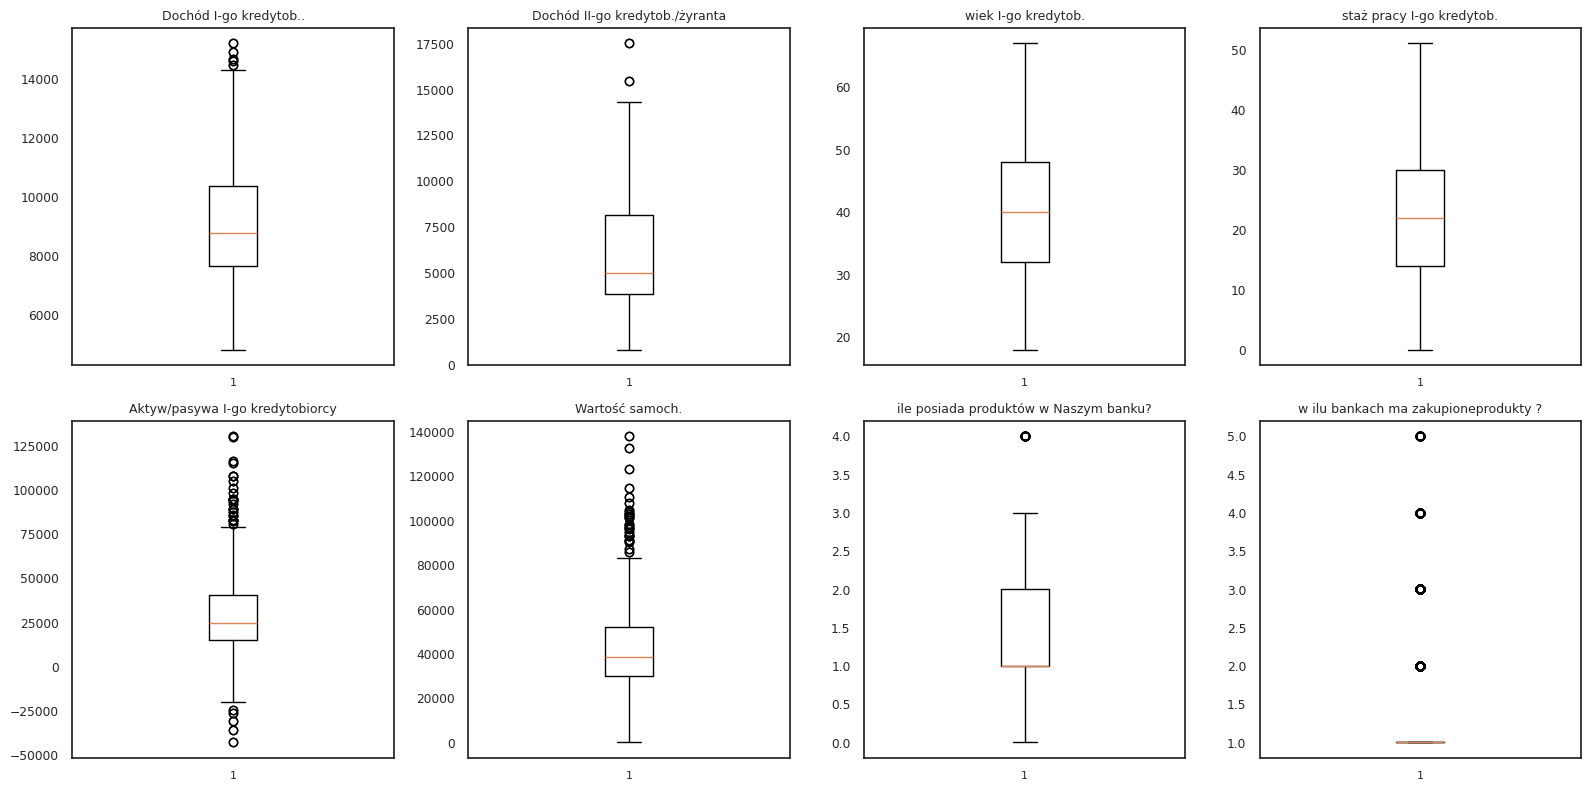

In [148]:
# Visualize outliers before treatment
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(num_columns):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(col, fontsize=9)
    axes[idx].tick_params(axis='x', labelsize=8)
    
plt.tight_layout()
plt.show()

It does not make sense to remove outliers for the following columns:
* w ilu bankach ma zakupioneprodukty ?
* ile posiada produktów w Naszym banku?

In [149]:
# Remove not applicable columns from num_columns
num_columns = [i for i in num_columns if i not in ['w ilu bankach ma zakupioneprodukty ?', 'ile posiada produktów w Naszym banku?']]

# Cap outliers using IQR method
X_train_capped = X_train.copy()
X_val_capped = X_val.copy()
X_test_capped = X_test.copy()

# Store bounds calculated from training data
bounds_dict = {}

for col in num_columns:
    # Calculate bounds ONLY from training data
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Store bounds for later use
    bounds_dict[col] = (lower_bound, upper_bound)
    
    # Count outliers before capping (training set)
    outliers_lower = (X_train_capped[col] < lower_bound).sum()
    outliers_upper = (X_train_capped[col] > upper_bound).sum()
    
    # Apply capping to ALL sets using the same bounds
    X_train_capped[col] = X_train_capped[col].clip(lower=lower_bound, upper=upper_bound)
    X_val_capped[col] = X_val_capped[col].clip(lower=lower_bound, upper=upper_bound)
    X_test_capped[col] = X_test_capped[col].clip(lower=lower_bound, upper=upper_bound)
    
    print(f"{col}:")
    print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    print(f"  Outliers capped (lower): {outliers_lower}, (upper): {outliers_upper}")
    print()

print(f"Training set size unchanged: {X_train_capped.shape[0]}")
print(f"Validation set size unchanged: {X_val_capped.shape[0]}")
print(f"Test set size unchanged: {X_test_capped.shape[0]}")

Dochód I-go kredytob..:
  Lower bound: 3673.82, Upper bound: 14327.45
  Outliers capped (lower): 0, (upper): 8

Dochód II-go kredytob./żyranta:
  Lower bound: -2617.98, Upper bound: 14631.65
  Outliers capped (lower): 0, (upper): 2

wiek I-go kredytob.:
  Lower bound: 9.50, Upper bound: 69.50
  Outliers capped (lower): 0, (upper): 0

staż pracy I-go kredytob.:
  Lower bound: -10.00, Upper bound: 54.00
  Outliers capped (lower): 0, (upper): 0

Aktyw/pasywa I-go kredytobiorcy:
  Lower bound: -23569.17, Upper bound: 79472.14
  Outliers capped (lower): 9, (upper): 28

Wartość samoch.:
  Lower bound: -3734.04, Upper bound: 85810.38
  Outliers capped (lower): 0, (upper): 38

Training set size unchanged: 1680
Validation set size unchanged: 360
Test set size unchanged: 360


In [150]:
# Save intermediate capped data
train_capped = X_train_capped.copy()
train_capped[target_column] = y_train
train_capped['split'] = 'train'

val_capped = X_val_capped.copy()
val_capped[target_column] = y_val
val_capped['split'] = 'validation'

test_capped = X_test_capped.copy()
test_capped[target_column] = y_test
test_capped['split'] = 'test'

df_capped = pd.concat([train_capped, val_capped, test_capped], axis=0)
df_capped = df_capped.sort_index()
df_capped.to_excel('data/processed/4_capped_data.xlsx', index=False)

print(f"Saved capped data with shape: {df_capped.shape}")

Saved capped data with shape: (2400, 45)


## Standarization

In [151]:
scaler = StandardScaler()

# Fit on training data only
scaler.fit(X_train_capped[num_columns])

# Transform all three sets
X_train_normalized = X_train_capped.copy()
X_train_normalized[num_columns] = scaler.transform(X_train_capped[num_columns])

X_val_normalized = X_val_capped.copy()
X_val_normalized[num_columns] = scaler.transform(X_val_capped[num_columns])

X_test_normalized = X_test_capped.copy()
X_test_normalized[num_columns] = scaler.transform(X_test_capped[num_columns])

# Verify
print("Normalized training set:")
print(X_train_normalized[num_columns].describe().round(3))
print(f"\nShapes: X_train {X_train_normalized.shape}, X_val {X_val_normalized.shape}, X_test {X_test_normalized.shape}")

Normalized training set:
       Dochód I-go kredytob..  Dochód II-go kredytob./żyranta  \
count                1680.000                        1680.000   
mean                    0.000                          -0.000   
std                     1.000                           1.000   
min                    -2.324                          -2.009   
25%                    -0.774                          -0.849   
50%                    -0.168                          -0.426   
75%                     0.674                           0.805   
max                     2.845                           3.285   

       wiek I-go kredytob.  staż pracy I-go kredytob.  \
count             1680.000                   1680.000   
mean                -0.000                      0.000   
std                  1.000                      1.000   
min                 -1.982                     -1.959   
25%                 -0.706                     -0.697   
50%                  0.022                     

In [152]:
# Save intermediate normalized data
train_normalized = X_train_normalized.copy()
train_normalized[target_column] = y_train
train_normalized['split'] = 'train'

val_normalized = X_val_normalized.copy()
val_normalized[target_column] = y_val
val_normalized['split'] = 'validation'

test_normalized = X_test_normalized.copy()
test_normalized[target_column] = y_test
test_normalized['split'] = 'test'


df_normalized = pd.concat([train_normalized, val_normalized, test_normalized], axis=0)
df_normalized = df_normalized.sort_index()
df_normalized.to_excel('data/processed/5_normalized_data.xlsx', index=False)

print(f"Saved normalized data with shape: {df_normalized.shape}")

Saved normalized data with shape: (2400, 45)


## Correlation

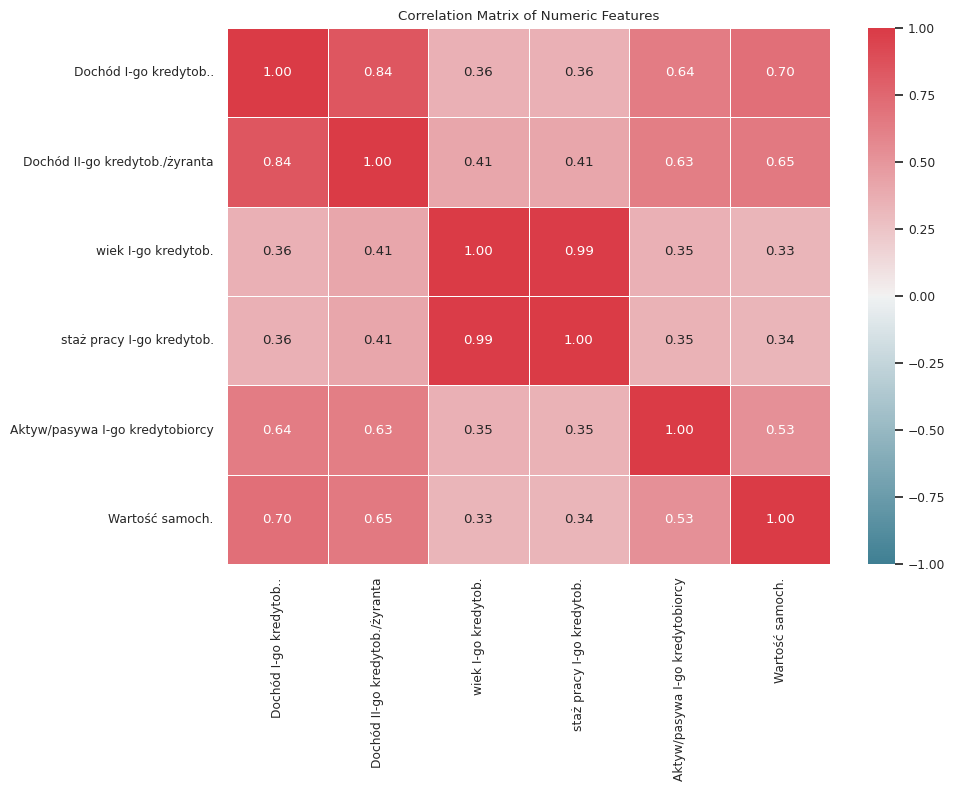

In [153]:
# Correlation analysis for numeric variables
data_correlations = X_train_normalized[num_columns].corr()

sns.set_theme(font_scale=0.8, style="white")
plt.figure(figsize=(10, 8))
sns.heatmap(data_correlations, annot=True, cmap=sns.diverging_palette(220, 10, as_cmap=True), 
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

Based on the correlation heatmap one highly correlated variable should be removed. The `staż pracy I-go kredytob.` will be removed due to high correlation (0.99) with `wiek I-go kredytob.`

In [154]:
# Remove highly correlated feature
num_columns.remove('staż pracy I-go kredytob.')

# Update all datasets
X_train_normalized = X_train_normalized.drop(columns=['staż pracy I-go kredytob.'])
X_val_normalized = X_val_normalized.drop(columns=['staż pracy I-go kredytob.'])
X_test_normalized = X_test_normalized.drop(columns=['staż pracy I-go kredytob.'])

print(f"Updated shapes: X_train {X_train_normalized.shape}, X_val {X_val_normalized.shape}, X_test {X_test_normalized.shape}")

Updated shapes: X_train (1680, 42), X_val (360, 42), X_test (360, 42)


In [155]:
# Save intermediate data after removing correlated features
train_normalized = X_train_normalized.copy()
train_normalized[target_column] = y_train
train_normalized['split'] = 'train'

val_normalized = X_val_normalized.copy()
val_normalized[target_column] = y_val
val_normalized['split'] = 'validation'

test_normalized = X_test_normalized.copy()
test_normalized[target_column] = y_test
test_normalized['split'] = 'test'


df_normalized = pd.concat([train_normalized, val_normalized, test_normalized], axis=0)
df_normalized = df_normalized.sort_index()
df_normalized.to_excel('data/processed/6_data_without_correlated_features.xlsx', index=False)

print(f"Saved normalized data with shape: {df_normalized.shape}")

Saved normalized data with shape: (2400, 44)


# Cluster Analysis

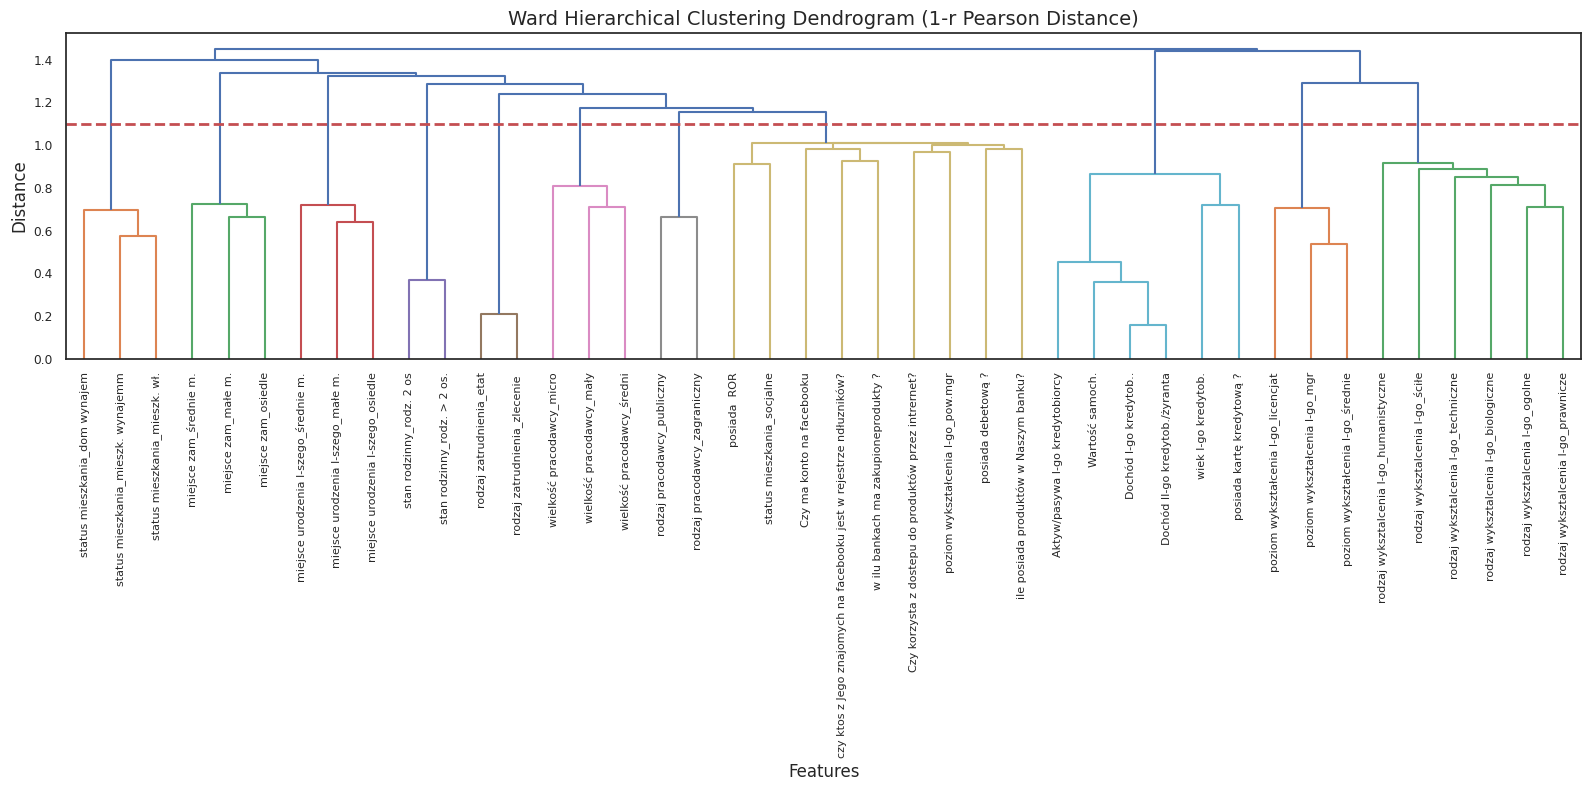

Linkage matrix shape: (41, 4)
Number of features clustered: 42


In [156]:
correlation_matrix = X_train_normalized.corr()

# Convert correlation to distance: distance = 1 - |correlation|
# Using absolute correlation ensures both positive and negative correlations are treated as similarity
distance_matrix = 1 - correlation_matrix.abs()

# Perform Ward linkage
condensed_distance = squareform(distance_matrix, checks=False)
linkage_matrix = linkage(condensed_distance, method='ward')

# Plot
plt.figure(figsize=(16, 8))

dendrogram(
    linkage_matrix,
    labels=X_train_normalized.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=8
)

plt.axhline(y=1.1, color='r', linestyle='--', linewidth=2, label='Cut-off threshold = 1.1')
plt.title('Ward Hierarchical Clustering Dendrogram (1-r Pearson Distance)', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Linkage matrix shape: {linkage_matrix.shape}")
print(f"Number of features clustered: {len(X_train_normalized.columns)}")

In [157]:
# Cut dendrogram at distance threshold = 1.1
distance_threshold = 1.1
cluster_labels = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# Create dictionary mapping cluster to variable names
cluster_dict = {}
for idx, feature in enumerate(X_train_normalized.columns):
    cluster_id = cluster_labels[idx]
    if cluster_id not in cluster_dict:
        cluster_dict[cluster_id] = []
    cluster_dict[cluster_id].append(feature)

# Display clusters
print(f"Total number of clusters: {len(cluster_dict)}\n")
for cluster_id, features in sorted(cluster_dict.items()):
    print(f"Cluster {cluster_id} ({len(features)} features):")
    for feature in features:
        print(f"  - {feature}")
    print()

Total number of clusters: 11

Cluster 1 (3 features):
  - status mieszkania_dom wynajem
  - status mieszkania_mieszk. wynajemm
  - status mieszkania_mieszk. wł.

Cluster 2 (3 features):
  - miejsce zam_małe m.
  - miejsce zam_osiedle
  - miejsce zam_średnie m.

Cluster 3 (3 features):
  - miejsce urodzenia I-szego_małe m.
  - miejsce urodzenia I-szego_osiedle
  - miejsce urodzenia I-szego_średnie m.

Cluster 4 (2 features):
  - stan rodzinny_rodz. 2 os
  - stan rodzinny_rodz. > 2 os.

Cluster 5 (2 features):
  - rodzaj zatrudnienia_etat
  - rodzaj zatrudnienia_zlecenie 

Cluster 6 (3 features):
  - wielkość pracodawcy_mały
  - wielkość pracodawcy_micro
  - wielkość pracodawcy_średni

Cluster 7 (2 features):
  - rodzaj pracodawcy_publiczny
  - rodzaj pracodawcy_zagraniczny

Cluster 8 (9 features):
  - posiada  ROR
  - posiada debetową ?
  - Czy korzysta z dostepu do produktów przez intrernet?
  - Czy ma konto na facebooku
  - czy ktos z Jego znajomych na facebooku jest w rejestrze ndłuz

In [158]:
selected_features = [
    'status mieszkania_dom wynajem',
    'miejsce zam_małe m.',
    'miejsce urodzenia I-szego_osiedle',
    'rodzaj zatrudnienia_zlecenie ',
    'rodzaj pracodawcy_publiczny',
    'Czy ma konto na facebooku',
    'poziom wykształcenia I-go_pow.mgr',
    'Wartość samoch.',
    'posiada kartę kredytową ?',
    'rodzaj wyksztalcenia I-go_humanistyczne',
    'rodzaj wyksztalcenia I-go_ogolne'
]

X_train_selected = X_train_normalized[selected_features]
X_val_selected = X_val_normalized[selected_features]
X_test_selected = X_test_normalized[selected_features]

print(f"Training set: {X_train_selected.shape}")
print(f"Validation set: {X_val_selected.shape}")
print(f"Test set: {X_test_selected.shape}")
print(f"\nSelected features: {len(selected_features)}")

Training set: (1680, 11)
Validation set: (360, 11)
Test set: (360, 11)

Selected features: 11


# Classification

The following models will be trained:
1. Decision Tree Classifier
2. Random Forest Classifier
3. Logistic Regression
4. Naive Bayes (Gaussian)

In [159]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=seed),
    'Random Forest': RandomForestClassifier(random_state=seed, n_estimators=100),
    'Logistic Regression': LogisticRegression(random_state=seed, max_iter=1000),
    'Naive Bayes': GaussianNB()
}

## Training

In [160]:
results = {}

for model_name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print(f"{'='*50}")
    
    # Train the model
    model.fit(X_train_selected, y_train)
    
    # Predictions on training set
    y_train_pred = model.predict(X_train_selected)
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val_selected)
    
    # Store results
    results[model_name] = {
        'model': model,
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_precision': precision_score(y_val, y_val_pred, average='weighted'),
        'val_recall': recall_score(y_val, y_val_pred, average='weighted'),
        'val_f1': f1_score(y_val, y_val_pred, average='weighted'),
        'y_val_pred': y_val_pred
    }
    
    print(f"\nTraining Accuracy: {results[model_name]['train_accuracy']:.4f}")
    print(f"Validation Accuracy: {results[model_name]['val_accuracy']:.4f}")
    print(f"Validation Precision: {results[model_name]['val_precision']:.4f}")
    print(f"Validation Recall: {results[model_name]['val_recall']:.4f}")
    print(f"Validation F1-Score: {results[model_name]['val_f1']:.4f}")


Training Decision Tree...

Training Accuracy: 0.9994
Validation Accuracy: 0.9639
Validation Precision: 0.9642
Validation Recall: 0.9639
Validation F1-Score: 0.9639

Training Random Forest...

Training Accuracy: 0.9994
Validation Accuracy: 0.9583
Validation Precision: 0.9587
Validation Recall: 0.9583
Validation F1-Score: 0.9583

Training Logistic Regression...

Training Accuracy: 0.8976
Validation Accuracy: 0.9222
Validation Precision: 0.9227
Validation Recall: 0.9222
Validation F1-Score: 0.9222

Training Naive Bayes...

Training Accuracy: 0.5583
Validation Accuracy: 0.5611
Validation Precision: 0.6786
Validation Recall: 0.5611
Validation F1-Score: 0.4747


## Results

In [161]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['train_accuracy'] for m in results.keys()],
    'Val Accuracy': [results[m]['val_accuracy'] for m in results.keys()],
    'Val Precision': [results[m]['val_precision'] for m in results.keys()],
    'Val Recall': [results[m]['val_recall'] for m in results.keys()],
    'Val F1-Score': [results[m]['val_f1'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Val Accuracy', ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))


MODEL COMPARISON
              Model  Train Accuracy  Val Accuracy  Val Precision  Val Recall  Val F1-Score
      Decision Tree        0.999405      0.963889       0.964247    0.963889      0.963882
      Random Forest        0.999405      0.958333       0.958687    0.958333      0.958325
Logistic Regression        0.897619      0.922222       0.922692    0.922222      0.922201
        Naive Bayes        0.558333      0.561111       0.678636    0.561111      0.474715


## Confusion matrix

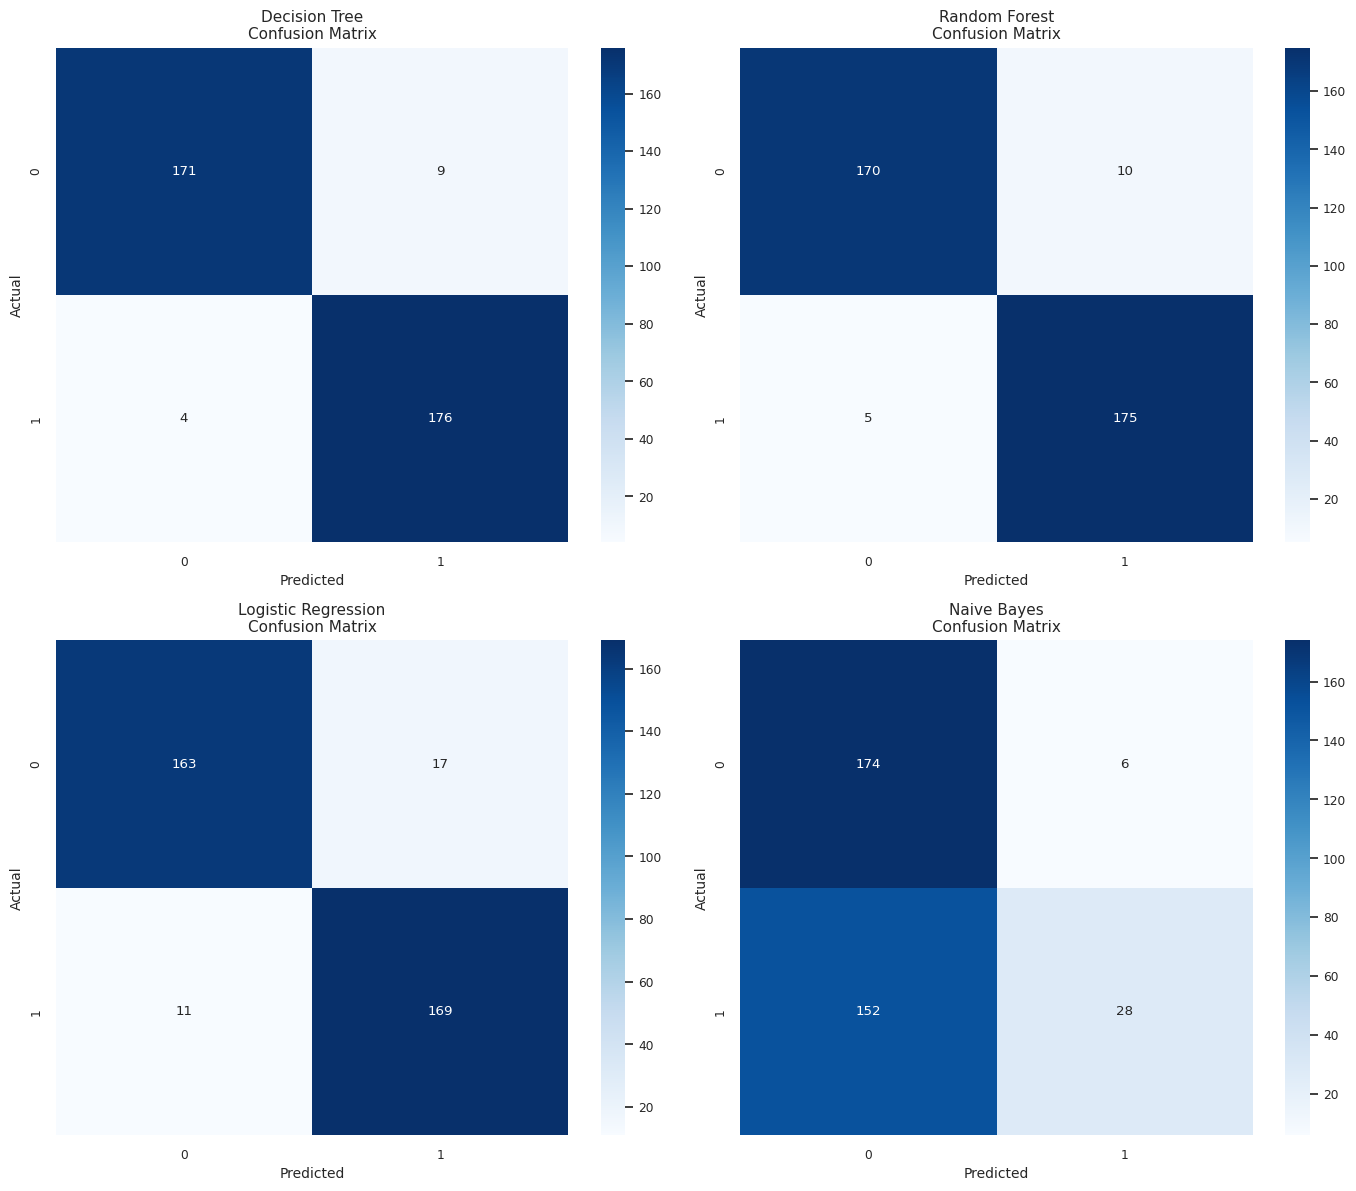

In [162]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_val, result['y_val_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

## Classification reports

In [163]:
for model_name, result in results.items():
    print(f"\n{'='*60}")
    print(f"{model_name} - Classification Report (Validation Set)")
    print(f"{'='*60}")
    print(classification_report(y_val, result['y_val_pred']))


Decision Tree - Classification Report (Validation Set)
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       180
           1       0.95      0.98      0.96       180

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360


Random Forest - Classification Report (Validation Set)
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       180
           1       0.95      0.97      0.96       180

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360


Logistic Regression - Classification Report (Validation Set)
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       180
           1       0.91      0.94      0.92       180

    accu

## ROC Curves

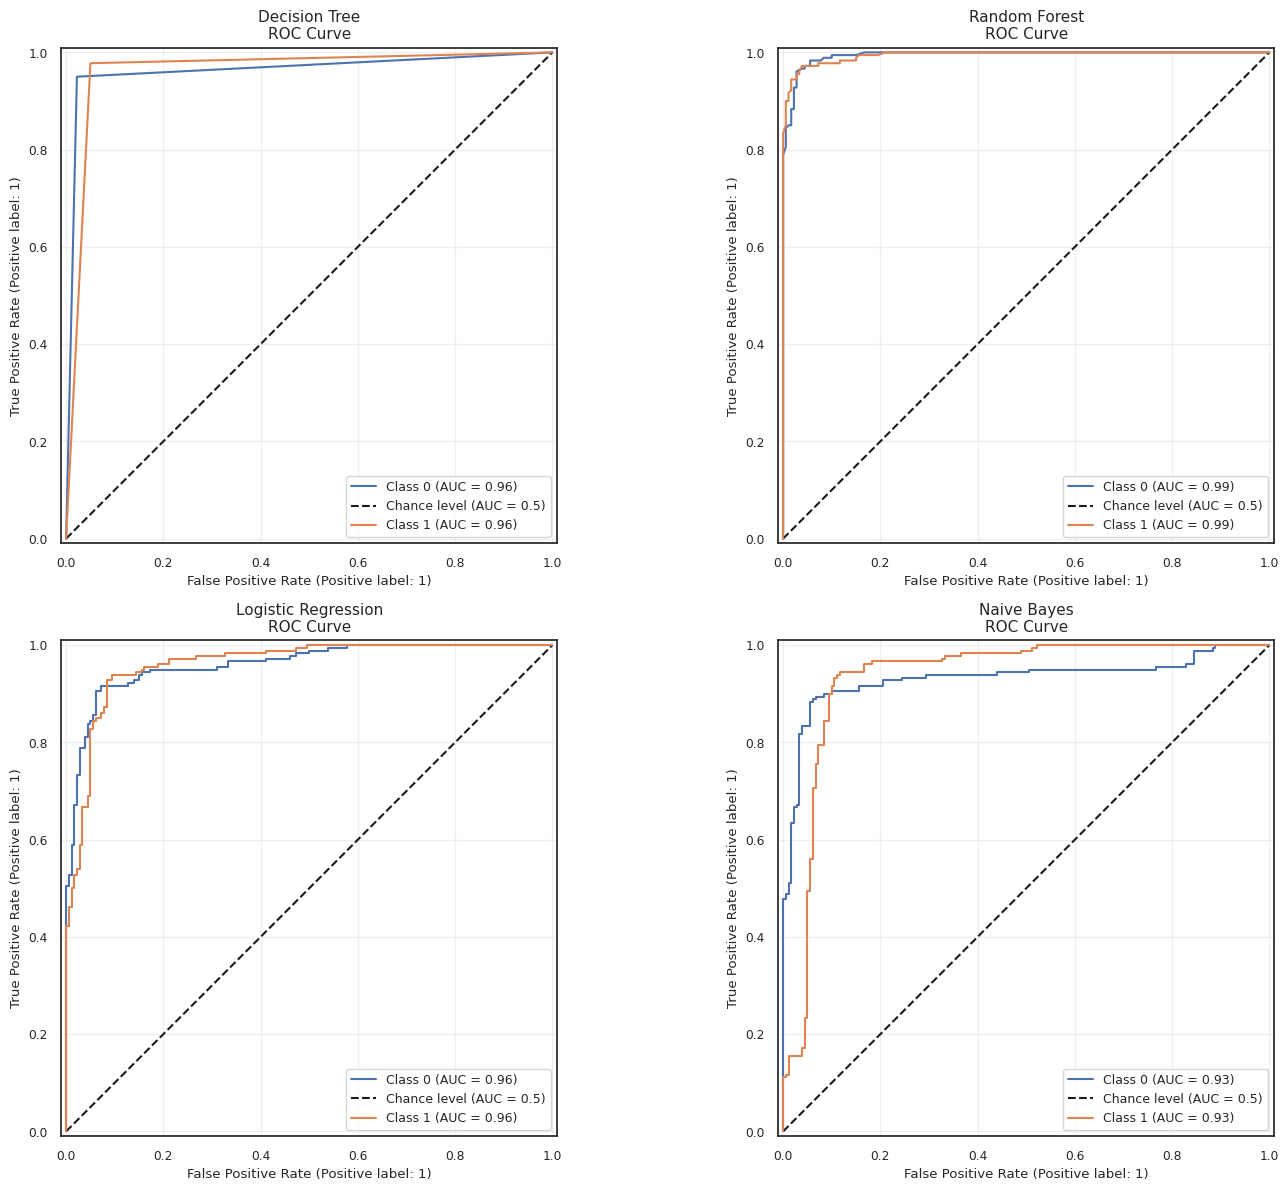

In [ ]:
# ROC Curves for all models using RocCurveDisplay
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (model_name, result) in enumerate(results.items()):
    model = result['model']
    
    classes = np.unique(y_val)
    
    for class_label in classes:
        RocCurveDisplay.from_estimator(
            model,
            X_val_selected,
            y_val,
            pos_label=class_label,
            ax=axes[idx],
            name=f'Class {class_label}',
            plot_chance_level=(class_label == classes[0])  # Only plot once
        )
    
    axes[idx].set_title(f'{model_name}\nROC Curve', fontsize=11)
    axes[idx].grid(alpha=0.3)
    axes[idx].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

## Others

### Random forest feature importance

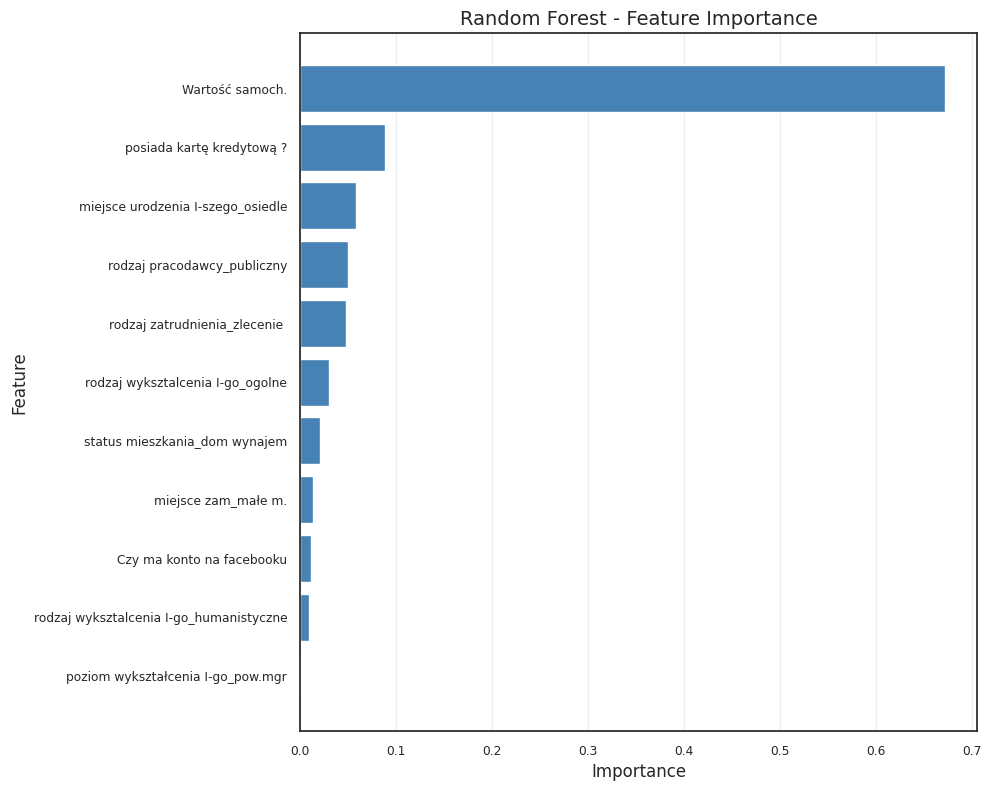

In [166]:
# Feature Importance for Random Forest
model = results['Random Forest']['model']

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)


plt.figure(figsize=(10, 8))
plt.barh(range(len(importance_df)), importance_df['Importance'].values[::-1], color='steelblue')
plt.yticks(range(len(importance_df)), importance_df['Feature'].values[::-1])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Decision Tree Visualization

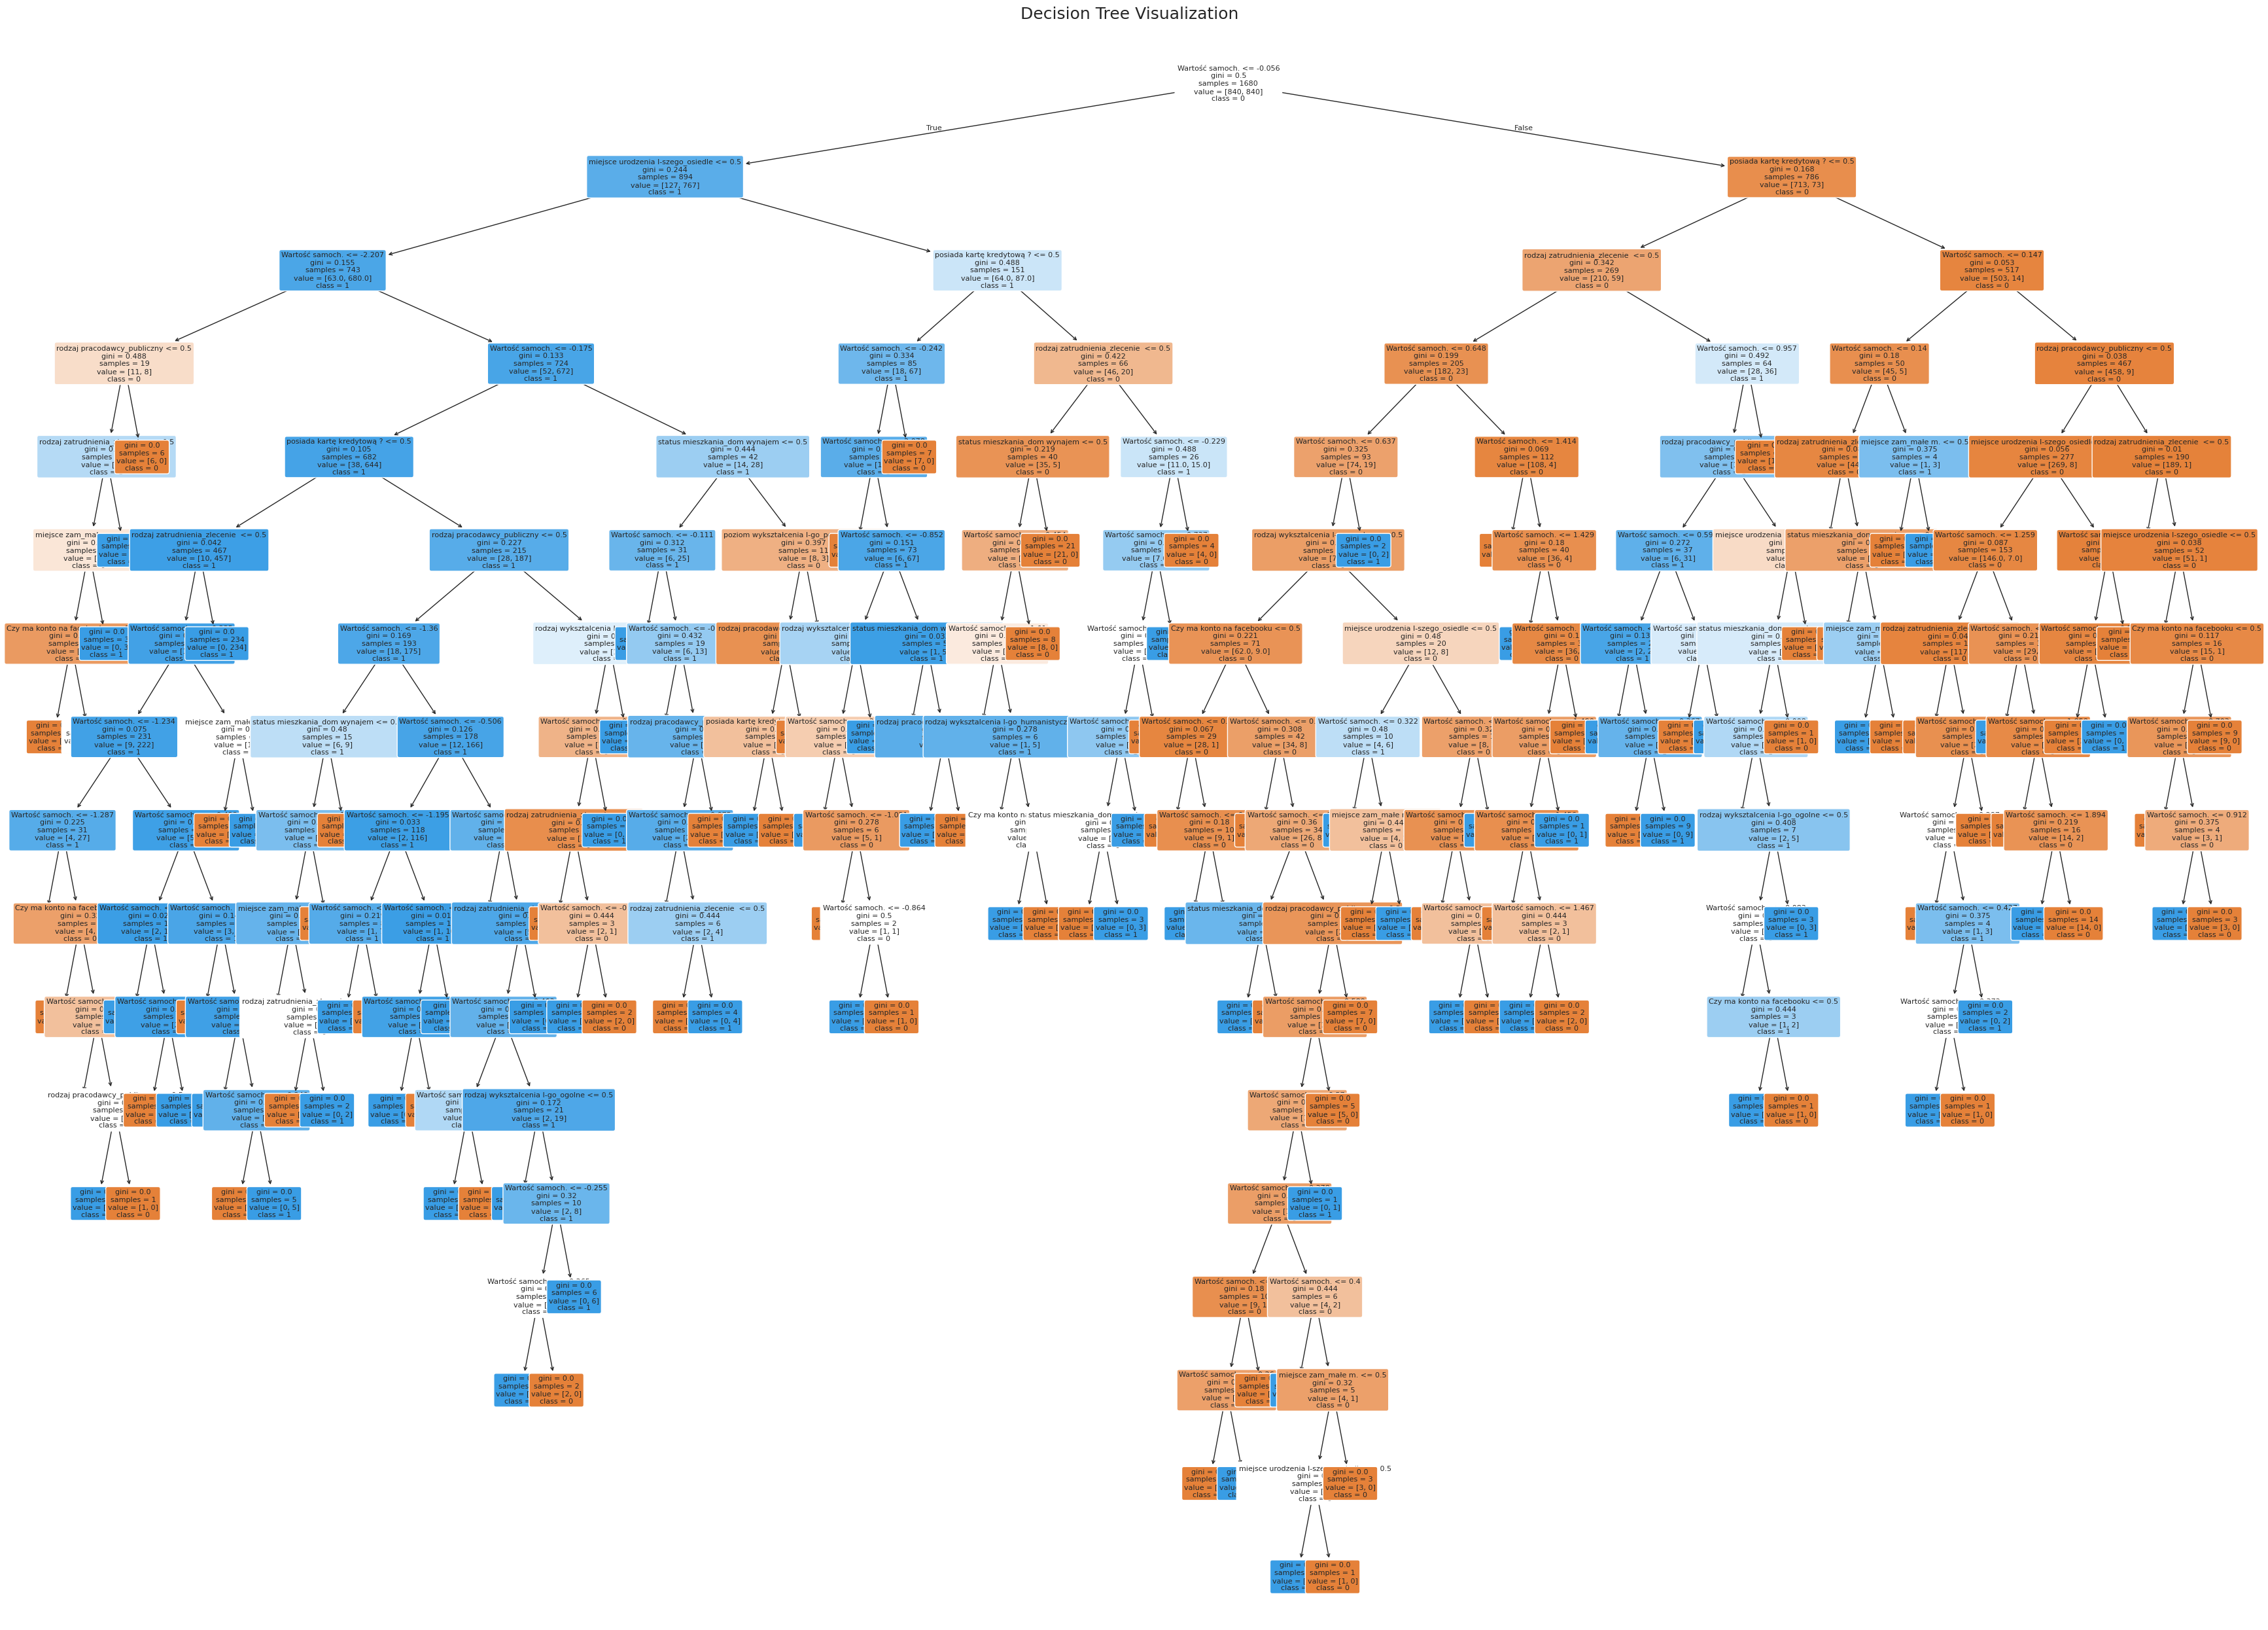

In [171]:
fig, ax = plt.subplots(figsize=(35, 25))
plot_tree(
    results['Decision Tree']['model'],
    feature_names=selected_features,
    class_names=[str(c) for c in results['Decision Tree']['model'].classes_],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
plt.title('Decision Tree Visualization', fontsize=18, pad=20)
plt.tight_layout()
plt.show()